In [1]:
# B. Cyclical Learning Rate (CLR) - Đây mới là thứ bạn đang tìm
# CLR cho phép LR dao động giữa một mức min và max theo hình sin hoặc hình tam giác.

# Lợi ích: Khi mô hình đứng yên, ở chu kỳ sau, LR sẽ tự động tăng vọt lên lại. Cú hích này giúp mô hình văng ra khỏi Local Minima để tìm vùng tối ưu tốt hơn.

# C. Warm Restarts (Cosine Annealing)
# Cứ sau một số epoch nhất định, LR sẽ được reset về mức cực đại ban đầu rồi giảm dần theo hình cosin. Đây là "chiêu" cực mạnh để phá vỡ các điểm bế tắc.
# Structured Pruning
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import tensorflow_model_optimization as tfmot #     [TFMOT] Nhúng thư viện tối ưu hóa
import numpy as np
import pandas as pd
import glob
from PIL import Image

# ==========================================
# CẤU HÌNH THÔNG SỐ
# ==========================================
IMG_SIZE = 32
NUM_CLASSES = 10
EPOCHS = 100
BATCH_SIZE = 8
DROPOUT_RATE = 0.3
EASTOP = 30
REDUCELR = 6
MINLR = 0.5e-5
VAL_SPLIT = 0.3
DENSE = 64
ALPHA= 0.5
MONITOR = 'val_accuracy'



# DATA ======================================================================
# ĐƯỜNG DẪN DATASET
TRAIN_DIR = 'C:/DUT/Ki_2/Edge_AI/dataset/train'
TEST_DIR = 'C:/DUT/Ki_2/Edge_AI/dataset/test'

# DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([
    layers.RandomContrast(0.1, seed=123),
    layers.RandomZoom(0.05, seed=123, fill_mode='nearest'),      
    layers.RandomRotation(0.05, seed=123, fill_mode='nearest'),
    layers.RandomTranslation(0.05, 0.05, seed=123, fill_mode='nearest'), 
    layers.RandomBrightness(factor=0.05, value_range=(0.0, 1.0), seed=123)
])
# data_augmentation = tf.keras.Sequential([
#     layers.RandomContrast(0.2, seed=123),
#     layers.RandomZoom(0.15, seed=123, fill_mode='nearest'),      
#     layers.RandomRotation(0.1, seed=123, fill_mode='nearest'),
#     layers.RandomTranslation(0.1, 0.1, seed=123, fill_mode='nearest'), 
#     layers.RandomBrightness(factor=0.2, value_range=(0.0, 1.0), seed=123)
# ])
# Thêm hàm chuyển đổi One-Hot cho Dataset
def to_one_hot(image, label):
    # NUM_CLASSES = 10
    one_hot_label = tf.one_hot(label, depth=NUM_CLASSES)
    return image, one_hot_label
normalization_layer = layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE


train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)


train_ds = (
    train_ds
    # 1. Chuẩn hóa ảnh (0-1)
    .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    # 2. Chuyển nhãn sang One-Hot (Bắt buộc để dùng Label Smoothing)
    .map(lambda x, y: to_one_hot(x, y), num_parallel_calls=AUTOTUNE)
    # 3. Cache dữ liệu đã chuẩn hóa và One-hot
    .cache()  
    # 4. Shuffle (Dùng buffer_size vừa đủ để không tràn RAM)
    .shuffle(buffer_size=1000) 
    # 5. Data Augmentation (Thực hiện TRÊN nhãn One-hot vẫn được, vì Augment chỉ tác động lên x)
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    # 6. Prefetch để tăng tốc GPU/CPU
    .prefetch(buffer_size=AUTOTUNE)
)
val_ds = (
    val_ds
    # 1. Chuẩn hóa ảnh (0-1)
    .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    # 2. Chuyển nhãn sang One-Hot (Bắt buộc để dùng Label Smoothing)
    .map(lambda x, y: to_one_hot(x, y), num_parallel_calls=AUTOTUNE)
    # 3. Cache dữ liệu đã chuẩn hóa và One-hot
    .cache()  
    # 4. Prefetch để tăng tốc GPU/CPU
    .prefetch(buffer_size=AUTOTUNE)
)
# DATA ======================================================================



# BUILD MODEL ======================================================================
def make_divisible(v, divisor=16, min_value=None):
    """
    Đảm bảo mọi lớp đều có số lượng filter chia hết cho `divisor` (16).
    """
    if min_value is None:
        min_value = divisor
    # Công thức làm tròn đến bội số gần nhất
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    # Đảm bảo việc làm tròn xuống không làm mất quá 10% số lượng filter
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v

def bottleneck_block(inputs, filters, stride, expansion=6):
    """
    Khối Inverted Residual Block chuẩn MobileNetV2
    """
    in_channels = inputs.shape[-1]
    
    # Bước 1: Expansion (1x1 Conv) - Phóng to
    # Bỏ qua bước này nếu expansion = 1 (thường dùng ở lớp đầu tiên)
    if expansion > 1:
        x = layers.Conv2D(expansion * in_channels, (1, 1), padding='same', use_bias=False)(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu6')(x)
    else:
        x = inputs

    # Bước 2: Depthwise (3x3) - Nơi xử lý STRIDE thay cho MaxPooling
    x = layers.DepthwiseConv2D((3, 3), strides=(stride, stride), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu6')(x)

    # Bước 3: Projection (1x1 Conv) - Bóp nhỏ (Linear Activation)
    x = layers.Conv2D(filters, (1, 1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    # LƯU Ý: Không dùng ReLU ở đây để tránh mất mát thông tin (Linear Bottleneck)

    # Bước 4: Residual Connection (Cộng gộp)
    # Chỉ cộng khi kích thước ảnh (stride=1) và số kênh (in_channels == filters) không đổi
    if stride == 1 and in_channels == filters:
        x = layers.Add()([inputs, x])

    return x

def build_micro_model():
    # model = models.Sequential([
    #     layers.InputLayer(input_shape=(32, 32, 1)),

    #     layers.Conv2D(make_divisible(32 * ALPHA), (3, 3), strides=(2, 2), padding='same', use_bias=False),
    #     layers.BatchNormalization(),
    #     layers.Activation('relu6'),
        
    #     layers.SeparableConv2D(make_divisible(64 * ALPHA), (3, 3), strides=(2, 2), padding='same', use_bias=False),
    #     layers.BatchNormalization(),
    #     layers.Activation('relu6'),
        
    #     layers.SeparableConv2D(make_divisible(128 * ALPHA), (3, 3), strides=(2, 2), padding='same', use_bias=False),
    #     layers.BatchNormalization(),
    #     layers.Activation('relu6'),

    #     layers.SeparableConv2D(make_divisible(128 * ALPHA), (3, 3), strides=(2, 2), padding='same', use_bias=False),
    #     layers.BatchNormalization(),
    #     layers.Activation('relu6'),
        
    #     layers.GlobalAveragePooling2D(),
    #     layers.Dense(NUM_CLASSES, activation='softmax')
    # ])
    # return model

    # Lớp đầu vào
    inputs = layers.Input(shape=(32, 32, 1))

    # Lớp Conv đầu tiên: Có thể dùng stride=2 ngay tại đây để giảm RAM lập tức
    # Ảnh 32x32 sẽ biến thành 16x16 ngay sau lớp này
    x = layers.Conv2D(32, (3, 3), strides=(2, 2), padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu6')(x)

    # Thay thế cụm SeparableConv2D + MaxPooling bằng Bottleneck + Stride=2
    # Đầu vào: 16x16x32
    
    # Khối 1: Tăng filter lên 64, giảm size xuống 8x8
    x = bottleneck_block(x, filters=64, stride=2, expansion=2)
    
    # Khối 2: Tăng filter lên 128, giảm size xuống 4x4
    x = bottleneck_block(x, filters=128, stride=2, expansion=2)
    
    # Khối 3: Giữ nguyên size 4x4, giữ nguyên 128 filters để học sâu hơn
    x = bottleneck_block(x, filters=128, stride=1, expansion=2)

    # Đóng gói và xuất kết quả
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Khởi tạo model gốc
base_model = build_micro_model()
# Câu trả lời cực kỳ thú vị: AI Instruction không làm Bottleneck nhanh hơn SeparableConv, nhưng nó làm cho khoảng cách về tốc độ giữa hai cái này trở nên cực kỳ nhỏ.
# BUILD MODEL ======================================================================



# CALLBACK ======================================================================
class AccuracyTracker(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_val_acc = 0.0
        self.best_val_loss = 10.0

    def on_epoch_end(self, epoch, logs=None):
        current_val_acc = logs.get("val_accuracy")
        current_val_loss = logs.get("val_loss")
        if current_val_acc > self.best_val_acc:
            diff = current_val_acc - self.best_val_acc
            print(f"\n✅ Epoch {epoch+1}: Val-Accuracy tăng thêm {diff:.4f}! (Từ {self.best_val_acc:.4f} -> {current_val_acc:.4f})")
            self.best_val_acc = current_val_acc
        
        if current_val_loss < self.best_val_loss:
            diff_loss = self.best_val_loss - current_val_loss
            print(f"✅ Epoch {epoch+1}: Val-Loss giảm thêm {diff_loss:.4f}! (Từ {self.best_val_loss:.4f} -> {current_val_loss:.4f})")
            self.best_val_loss = current_val_loss


checkpoint = callbacks.ModelCheckpoint(
    'traffic_sign_model.h5', 
    monitor=MONITOR, 
    save_best_only=True, 
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor=MONITOR, 
    factor=0.2, 
    patience=REDUCELR, 
    min_lr=MINLR, 
    verbose=1
)

early_stopping = callbacks.EarlyStopping(
    monitor=MONITOR, 
    patience=EASTOP, 
    restore_best_weights=True
)

# [TFMOT] Thêm UpdatePruningStep vào danh sách callbacks
callbacks_list = [
    AccuracyTracker(), 
    reduce_lr, 
    checkpoint, 
    early_stopping,
    # tfmot.sparsity.keras.UpdatePruningStep() # Cập nhật mức độ Pruning sau mỗi step
]
# CALLBACK ======================================================================



# QUANTIZATION AWARE TRAINING ======================================================================
# Khởi tạo API của tfmot cho QAT
quantize_model = tfmot.quantization.keras.quantize_model

# Bọc mô hình cơ sở bằng các "node giả lập lượng tử"
qat_model = quantize_model(base_model)

# Compile mô hình QAT (Phải compile lại sau khi bọc)
qat_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
qat_model.summary()

history = qat_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list
)


# Bây giờ mới lưu file h5 chuẩn để load sau này mà không bị mismatch
qat_model.save('traffic_sign_cleaned_final.h5') 

print("✅ Đã lưu mô hình sạch sẽ, không còn lớp bọc!")
# QUANTIZATION AWARE TRAINING ======================================================================



Found 2000 files belonging to 10 classes.
Using 1400 files for training.
Found 2000 files belonging to 10 classes.
Using 600 files for validation.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 32, 32, 1)]          0         []                            
                                                                                                  
 quantize_layer (QuantizeLa  (None, 32, 32, 1)            3         ['input_1[0][0]']             
 yer)                                                                                             
                                                                                                  
 quant_conv2d (QuantizeWrap  (None, 16, 16, 32)           353       ['quantize_layer[0][0]']      
 perV2)                                   

c:\Users\ngong\AppData\Local\Programs\Python\Python311\Lib\site-packages\tf_keras\src\engine\training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


175/175 [==============================] - 14s 50ms/step - loss: 1.9998 - accuracy: 0.3507 - val_loss: 2.4135 - val_accuracy: 0.0983 - lr: 0.0010
Epoch 2/100
175/175 [==============================] - ETA: 0s - loss: 1.4356 - accuracy: 0.5993
Epoch 2: val_accuracy did not improve from 0.09833
175/175 [==============================] - 6s 35ms/step - loss: 1.4356 - accuracy: 0.5993 - val_loss: 2.6476 - val_accuracy: 0.0983 - lr: 0.0010
Epoch 3/100
175/175 [==============================] - ETA: 0s - loss: 1.0883 - accuracy: 0.7850
✅ Epoch 3: Val-Accuracy tăng thêm 0.5150! (Từ 0.0983 -> 0.6133)
✅ Epoch 3: Val-Loss giảm thêm 1.0581! (Từ 2.4135 -> 1.3554)

Epoch 3: val_accuracy improved from 0.09833 to 0.61333, saving model to traffic_sign_model.h5
175/175 [==============================] - 7s 42ms/step - loss: 1.0883 - accuracy: 0.7850 - val_loss: 1.3554 - val_accuracy: 0.6133 - lr: 0.0010
Epoch 4/100
175/175 [==============================] - ETA: 0s - loss: 0.9536 - accuracy: 0.8357
✅ E

# Continue

In [2]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot

# 1. Nạp model trong Scope của TFMOT để Keras hiểu các lớp QuantizeWrapper
with tfmot.quantization.keras.quantize_scope():
    # Nạp lại file đã train ở Cell 1
    loaded_model = tf.keras.models.load_model('traffic_sign_cleaned_final.h5')

print("✅ Đã nạp thành công Model có trọng số!")

# 2. Khởi tạo Converter từ model vừa nạp
# Converter sẽ tự động "Strip" (lột vỏ) các lớp bọc cho bạn
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 3. Cung cấp dữ liệu mẫu (Representative Dataset)
# CỰC KỲ QUAN TRỌNG: Để TFLite tính toán dải giá trị cho INT8
def representative_dataset():
    # Đảm bảo val_ds đã được định nghĩa ở cell này (hoặc nạp lại data)
    for images, _ in val_ds.unbatch().batch(1).take(100):
        yield [tf.cast(images, tf.float32)]

converter.representative_dataset = representative_dataset

# 4. Ép kiểu INT8 toàn phần để chạy nhanh trên ESP32-S3
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# 5. Thực hiện chuyển đổi và lưu file
tflite_model = converter.convert()

with open('traffic_sign_final_int8.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"🚀 Xuất file TFLite thành công! Kích thước: {len(tflite_model)/1024:.2f} KB")

✅ Đã nạp thành công Model có trọng số!
INFO:tensorflow:Assets written to: C:\Users\ngong\AppData\Local\Temp\tmp1cpaltr5\assets


INFO:tensorflow:Assets written to: C:\Users\ngong\AppData\Local\Temp\tmp1cpaltr5\assets
c:\Users\ngong\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


🚀 Xuất file TFLite thành công! Kích thước: 142.33 KB


# Model Evaluation

In [ ]:
import time
import numpy as np
import tensorflow as tf

# 1. Load TFLite Model và cấp phát bộ nhớ
interpreter = tf.lite.Interpreter(model_path="traffic_sign_final_int8.tflite")
interpreter.allocate_tensors()

# Lấy thông tin input/output
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_index = input_details[0]['index']
output_index = output_details[0]['index']

# Quan trọng: Lấy thông tin Quantization để chuẩn hóa ảnh đầu vào đúng kiểu INT8
input_scale, input_zero_point = input_details[0]['quantization']

# 2. Chuẩn bị biến lưu trữ kết quả benchmark
total_inference_time = 0
correct_predictions = 0
total_images = 0

print("🚀 Đang bắt đầu đánh giá Model...")
print("-" * 40)

# Duyệt qua tập Validation (val_ds đã định nghĩa ở các bước trước)
# Chúng ta unbatch để đo thời gian cho từng ảnh đơn lẻ
for images, labels in val_ds.unbatch().take(500):  # Test trên 500 mẫu
    total_images += 1
    
    # --- TIỀN XỬ LÝ (Preprocessing) ---
    # Chuyển ảnh về dạng mà model INT8 yêu cầu
    img_array = images.numpy()
    if input_scale != 0:
        img_array = img_array / input_scale + input_zero_point
    
    # Ép kiểu sang INT8 và thêm dimension batch (1, 32, 32, 3)
    input_data = np.expand_dims(img_array.astype(np.int8), axis=0)
    
    # --- INFERENCE (Đo thời gian) ---
    start_time = time.perf_counter()
    
    interpreter.set_tensor(input_index, input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_index)
    
    end_time = time.perf_counter()
    
    # Cộng dồn thời gian (tính bằng miligiây)
    total_inference_time += (end_time - start_time) * 1000
    
    # --- KIỂM TRA ĐỘ CHÍNH XÁC ---
    predicted_label = np.argmax(output_data[0])
    true_label = labels.numpy()
    
    # Comment cái này nếu không one-hot
    true_label_idx = np.argmax(labels.numpy()) # Lấy vị trí của số 1 trong mảng One-Hot

    if predicted_label == true_label_idx:
        correct_predictions += 1

# 3. TÍNH TOÁN VÀ LOG KẾT QUẢ
avg_inference_time = total_inference_time / total_images
accuracy = (correct_predictions / total_images) * 100

print("-" * 40)
print(f"📊 KẾT QUẢ BENCHMARK (Trên PC):")
print(f"🔹 Tổng số ảnh kiểm tra: {total_images}")
print(f"🔹 Độ chính xác (Accuracy): {accuracy:.2f}%")
print(f"🔹 Tổng thời gian Inference : {total_inference_time:.2f} ms")
print(f"🔹 Thời gian Inference trung bình: {avg_inference_time:.2f} ms / ảnh")
print("-" * 40)

🚀 Đang bắt đầu đánh giá Model...
----------------------------------------
----------------------------------------
📊 KẾT QUẢ BENCHMARK (Trên PC):
🔹 Tổng số ảnh kiểm tra: 500
🔹 Độ chính xác (Accuracy): 99.60%
🔹 Tổng thời gian Inference : 23.19 ms
🔹 Thời gian Inference trung bình: 0.05 ms / ảnh
----------------------------------------


# Chart

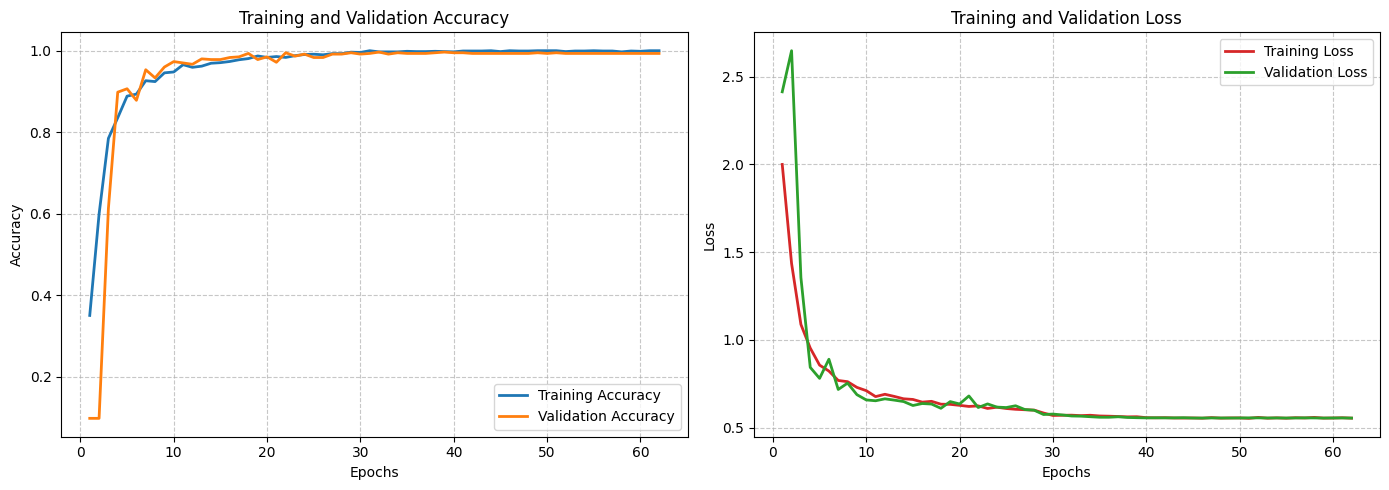

🚀 Đang tính toán dự đoán trên tập Validation...
1/1 [==============================] - 0s 69ms/step


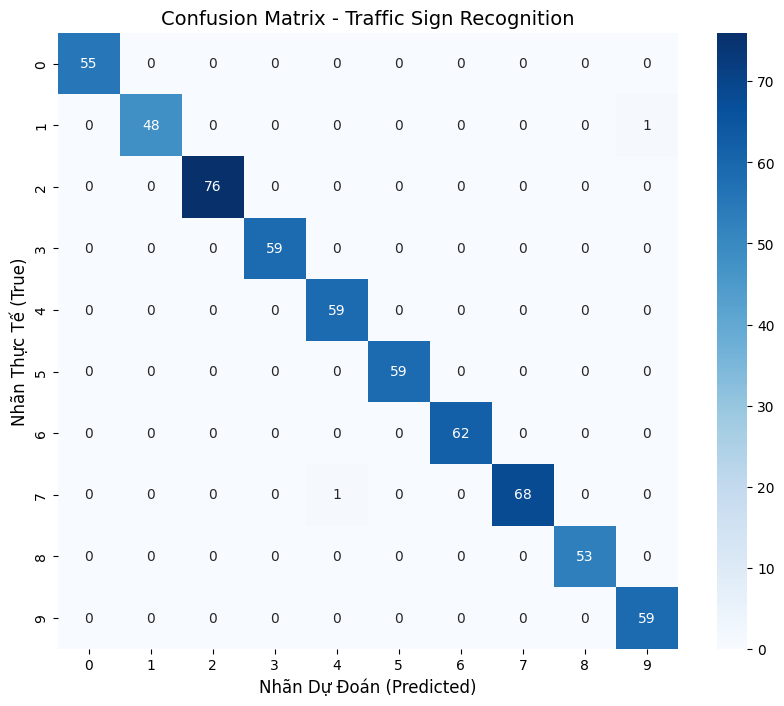

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ==========================================
# 1. HÀM VẼ BIỂU ĐỒ HISTORY (ACCURACY & LOSS)
# ==========================================
def plot_training_results(history):
    # Lấy dữ liệu từ object history của Keras
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2)
    plt.title('Training and Validation Accuracy', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Biểu đồ Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=12)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Gọi hàm ngay sau khi qat_model.fit()
plot_training_results(history)


# ==========================================
# 2. VẼ CONFUSION MATRIX (MA TRẬN NHẦM LẪN)
# ==========================================
print("🚀 Đang tính toán dự đoán trên tập Validation...")

# Dự đoán nhãn từ qat_model (dùng tập val_ds)
y_pred = []
y_true = []

# Duyệt qua từng batch trong val_ds để lấy nhãn thật và nhãn dự đoán
for images, labels in val_ds:
    # preds = qat_model.predict(images, verbose=0)
    # y_pred.extend(np.argmax(preds, axis=1))
    # y_true.extend(labels.numpy())

    # ONE-HOT======================================
    preds = qat_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    # 2. Xử lý y_true: Chuyển từ One-Hot (do Label Smoothing) về Integer
    # labels lúc này có dạng (batch_size, num_classes)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    # ONE-HOT======================================

# Tính Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Vẽ biểu đồ nhiệt Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(NUM_CLASSES), 
            yticklabels=range(NUM_CLASSES))

plt.title('Confusion Matrix - Traffic Sign Recognition', fontsize=14)
plt.xlabel('Nhãn Dự Đoán (Predicted)', fontsize=12)
plt.ylabel('Nhãn Thực Tế (True)', fontsize=12)
plt.show()

# Log

In [11]:
# ==========================================
# TEST TFLITE MODEL & XUẤT CSV (BẢN CHUẨN DUT)
# ==========================================
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf

# 1. Load ĐÚNG file TFLite mới nhất bạn vừa convert thành công
# (Hãy đảm bảo tên file này khớp với file ở Cell Convert)
MODEL_PATH = "traffic_sign_final_int8.tflite" 
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

# Lấy thông tin Input/Output
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_index = input_details[0]['index']
output_index = output_details[0]['index']

# Lấy thông tin Quantization (Cực kỳ quan trọng cho INT8)
input_scale, input_zero_point = input_details[0]['quantization']

# 2. Quét danh sách ảnh Test
# Lưu ý: Sắp xếp theo tên để đảm bảo thứ tự trong CSV
test_images_paths = glob.glob(os.path.join(TEST_DIR, '*.png'))
test_images_paths.sort() 

results = []

print(f"🚀 Đang xử lý {len(test_images_paths)} ảnh test...")

for img_path in test_images_paths:
    # Lấy ID từ tên file (ví dụ: '001.png' -> '001')
    img_id = os.path.basename(img_path).split('.')[0]
    
    # --- TIỀN XỬ LÝ (Phải khớp 100% với lúc Train) ---
    # Load ảnh dạng GRAYSCALE (vì model của bạn train với color_mode='grayscale')
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale')
    img_array = tf.keras.utils.img_to_array(img)
    
    # Bước A: Rescaling 1./255 (giống normalization_layer lúc train)
    img_array = img_array / 255.0
    
    # Bước B: Quantization Scaling (Ép float sang INT8)
    if input_scale != 0:
        img_array = (img_array / input_scale) + input_zero_point
    
    # Thêm batch dimension và ép kiểu int8
    input_data = np.expand_dims(img_array.astype(np.int8), axis=0)
    
    # --- CHẠY INFERENCE ---
    interpreter.set_tensor(input_index, input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_index)[0]
    
    # Lấy class có xác suất cao nhất
    predicted_class = np.argmax(output_data)
    
    results.append({'Id': img_id, 'Label': int(predicted_class)})

# 3. XUẤT FILE CSV
submission_df = pd.DataFrame(results)

# Đảm bảo cột Id được lưu đúng định dạng (ví dụ 0001 thay vì 1 nếu cần)
submission_df.to_csv('submission_edge_ai.csv', index=False)

print("-" * 30)
print(f"✅ Đã xuất file thành công: submission_edge_ai.csv")
print(f"🔹 Tổng cộng: {len(submission_df)} dòng.")
print(submission_df.head()) # Xem trước 5 dòng đầu

c:\Users\ngong\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


🚀 Đang xử lý 1000 ảnh test...
------------------------------
✅ Đã xuất file thành công: submission_edge_ai.csv
🔹 Tổng cộng: 1000 dòng.
      Id  Label
0  00000      4
1  00007      2
2  00012      2
3  00014      6
4  00022      1
